In [1]:
#this is all of my current work compiled 

In [2]:
import redback
print(redback.__version__)

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
15:42 bilby INFO    : Running bilby version: 2.3.0
15:42 redback INFO    : Running redback version: 1.12.1


1.12.1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
#updated redback imports? ASK GAVIN - some not working ? 
#should still do that - dont need any of these actually !! 
# these just are shortening things 

#comment all of this out to see if code still runs !! 
# import numpy as np
# import pandas as pd
# from redback.transient_models.phenomenological_models import exponential_powerlaw, fallback_lbol
# from redback.transient_models.magnetar_models import magnetar_only, basic_magnetar
# from redback.transient_models.magnetar_driven_ejecta_models import _ejecta_dynamics_and_interaction
# from redback.transient_models.shock_powered_models import  _shocked_cocoon, _csm_shock_breakout
import redback.interaction_processes as ip
import redback.sed as sed
# #from redback.sed import flux_density_to_spectrum, blackbody_to_spectrum
import redback.photosphere as photosphere
from astropy.cosmology import Planck18 as cosmo  # noqa
# #from redback.utils import (calc_kcorrected_properties, citation_wrapper, logger, get_csm_properties, nu_to_lambda,
#                            #lambda_to_nu, velocity_from_lorentz_factor, build_spectral_feature_list)
# #NEED THIS SINCE IT CONTAINS LAMBA TO NU !! 
# from redback.constants import day_to_s, solar_mass, km_cgs, au_cgs, speed_of_light, sigma_sb
# from inspect import isfunction
import astropy.units as uu
# from collections import namedtuple
# from scipy.interpolate import interp1d, RegularGridInterpolator


# import matplotlib.pyplot as plt



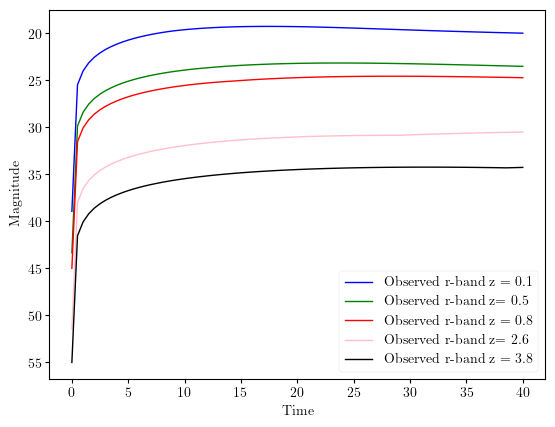

In [5]:
#plot lightcurves from Tables given for 1998bw to show peaks becoming redder at higher redshifts 

#import csv files for 1998bw at different redshifts
#read in txt files into pandas dataframes then write the dataframe to a csv file
sn1998bw_z_0_1 = pd.read_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.1.txt')
sn1998bw_z_0_1.to_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.1.csv', index = False)

sn1998bw_z_0_5 = pd.read_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.5.txt')
sn1998bw_z_0_5.to_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.5.csv', index = False)

sn1998bw_z_0_8 = pd.read_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.8.txt')
sn1998bw_z_0_8.to_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z0.8.csv', index = False)

#compare lightcurves for different redshifts of 1998bw in the same filter band 

time_1 = sn1998bw_z_0_1['day']
mag_r_1 = sn1998bw_z_0_1['r']

time_5 = sn1998bw_z_0_5['day']
mag_r_5 = sn1998bw_z_0_5['r']

time_8 = sn1998bw_z_0_8['day']
mag_r_8 = sn1998bw_z_0_8['r']

#include more redshifts to see what happens 

sn1998bw_z_2_6 = pd.read_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z2.6.txt')
sn1998bw_z_2_6.to_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z2.6.csv', index = False)

time_26 = sn1998bw_z_2_6['day']
mag_r_26 = sn1998bw_z_2_6['r']


sn1998bw_z_3_8 = pd.read_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z3.8.txt')
sn1998bw_z_3_8.to_csv('/Users/helenagrabham/Downloads/98_bw_models/98bw_z3.8.csv', index = False)

time_38 = sn1998bw_z_3_8['day']
mag_r_38 = sn1998bw_z_3_8['r']

plt.plot(time_1, mag_r_1, '-', label = 'Observed r-band z = 0.1', color = 'blue')
plt.plot(time_5, mag_r_5, '-', label = 'Observed r-band z= 0.5', color = 'green')
plt.plot(time_8, mag_r_8, '-', label = 'Observed r-band z = 0.8', color = 'red')
plt.plot(time_26, mag_r_26, '-', label = 'Observed r-band z= 2.6', color = 'pink')
plt.plot(time_38, mag_r_38, '-', label = 'Observed r-band z = 3.8', color = 'black')
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.legend()
plt.gca().invert_yaxis() #lower magnitudes = brighter
plt.show()

#at higher redshifts, object appears fainter, higher magnitude YES !! 
#peak is not shifting though ? 
#vertical gap between blue filter and red filter should widen 


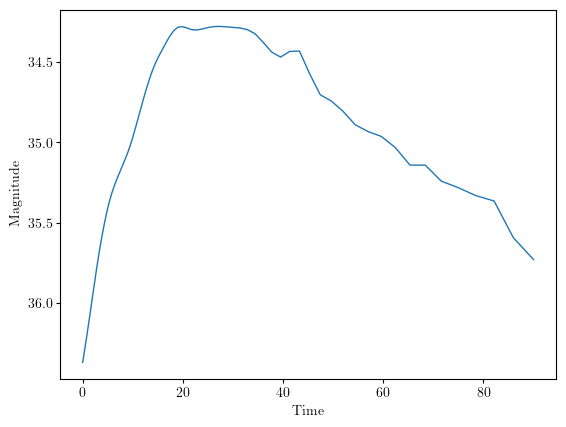

In [6]:
#plot singular lightcurve for model of 1998bw from redback

#define variables 
#rename tts as time
time = np.geomspace(0.01, 90, 200) 

#amplitude and redshift are defined at the end for plotting 

def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(time, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = time * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching K-CORRECTION !
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy - ENSURES FLUX IS IN CORRECT UNITS !!
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)
    
mag = sn1998bw_template(time, redshift=1, amplitude=0.001, output_format='magnitude', bands='bessellb')
plt.plot(time, mag)
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.gca().invert_yaxis() #lower magnitudes = brighter
plt.show()

In [ ]:
#now do the same for flux density
#have to introduce frequency to make this work - if i want flux density over a continuum have to introduce multiple frequencies
#do i still need these multiple frequencies for comparing to GRB events ? presuming yes so make sure frequency is in V band so I can use Av extinction properly with fitzpatrick99

time = np.geomspace(0.01, 90, 200) 

#for flux density i have to use frequency of the filter STATED AS REQUIRED IN REDBACK DOCUMENTATION !effective width = same order of mag so ok to use? check with gavin ? 
#how to import the filters information from redback entirely ? 
v_band_frequency = 8.58703e+13 #Hz 

#dont need to have specific frequency then converted into eavelength since i am using sncosmo now ! 
#bandwidth to get flux density over a range 
#besselv = band argument in model.bandflux --> use sncosmo for this, using the V band frequency bandpass
#function then integrates model SED over V bandpass at each time giving flux density in V band as function of time 

import sncosmo

band = sncosmo.get_bandpass('bessellv')
# Wavelengths (in Angstroms)
print(band.wave)  

# If you want frequencies (in Hz):
import astropy.constants as const
import astropy.units as u

freq = (const.c.value / (band.wave * 1e-10))  # Convert Angstrom to meters, then to Hz
print(freq)

v_wavelength = 	5477.70000 #angstroms 

#lambda_array = np.array([5477.70000])

#this converts angstrom wavelength back to metres then divides m/s by m 
#alternatively, keep wavelength in m and then change c to be angstrom/s

import astropy.constants as cc
#not working for some reason - just use the normal c value
#need to import in the actual definition? 
c = 3.0e8 #m/s

def lambda_to_nu(v_wavelength):
    """
    :param wavelength: wavelength in Angstrom
    :return: frequency in Hertz
    """
    return c / (v_wavelength* 1.e-10)
    #return speed_of_light_si / (v_wavelength* 1.e-10)

#try other def
# def lambda_to_nu(lambda_array):
#     # lambda_array in Angstroms
#     c = 2.99792458e18  # speed of light in Angstrom/s
#     return c / lambda_array

def sn1998bw_template(time, redshift, amplitude, **kwargs):
    
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(time, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = time * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)
    
#should i be changing my amplitude to be 1.0 since this is the original brightness of 1998bw ?? !! 
flux = sn1998bw_template(time, redshift=1, amplitude=0.001, output_format='flux_density', bands='bessellb', frequency = v_band_frequency)
plt.plot(time, flux)
plt.xlabel("Time")
plt.ylabel("Flux Density")
#plt.gca().invert_yaxis() #dont invert !!
plt.show()


In [7]:
#use interpolation to compare a GRB event to known 1998bw lightcurve data to find the f_1998bw ratio value 

#example 1:
#GRB 060218 SN 2006aj apparent magnitude = 17.22 in the r-band MUST BE ASSOCIATED WITH A SPECIFIC EPOCH 11 days 

#still generate time array ? 
times = np.geomspace(0.01, 90, 200)
z_event = 0.0335 #from table in paper
band = 'bessellr'

#compute magnitudes for all times for 1998bw
mags = sn1998bw_template(times, redshift=z_event,
    amplitude=1.0, 
    output_format='magnitude', 
    bands=band)

#interpolate to find magnitude at the desired epoch
#np.interp estimates the value of y at a given x positon 
epoch = 11.873
mag_at_epoch = np.interp(epoch, times, mags)

print(f"Observed magnitude of 1998bw at {epoch} days: {mag_at_epoch:.2f}")

#now calculate the final ratio - does data need to be taken from same telescope ? 
m_grb = 17.21

#now make the extinction corrections and k-correction using info from papers: 
#for GRB 060218 from paper Sollerman et al. 2006 
'''the following we will therefore adopt a total extinction of E(B − V) = 0.14 mag
Does this mean Av = ??? 0.14 x 3.1 ??? 
The final spectrum is taken closest in time to the maximum light in these bands, and indicate K-corrections of ∼0.02 mag in the V band, 
and 0.15 mag in R.
Using the sodium lines to estimate the reddening (see e.g., Munari & Zwitter 1997) provides E(B − V) = 0.127 for the Milky Way, 
and E(B − V) = 0.042 mag for the GRB host. This is consistent with adopting a total reddening of E(B − V) = 0.14 mag 
'''

#so take total Av = 0.14 x 3.1 

#COMMAND+CONTROL+/
#COMMENT AND UNCOMMENT THIS SECTION TO PROVE -----------------
#yes this calculation is correct however 
Av = 0.14 * 3.1
print("extinction =" ,Av)

#WHAT ABOUT K - CORRECTION TOO !! 
# from redback.utils import calc_kcorrected_properties -- Use this ? 
'''def calc_kcorrected_properties(frequency, redshift, time):
    """
    Perform k-correction

    :param frequency: observer frame frequency
    :param redshift: source redshift
    :param time: observer frame time
    :return: k-corrected frequency and source frame time
    """
    time = time / (1 + redshift)
    frequency = frequency * (1 + redshift)
    return frequency, time'''

#just add k on ?? or no 
#or minus k ? 

#A_v matters - is band dependent !! 

m_grb = m_grb - Av 

#----------------------------------------------------------------
mag_diff = m_grb - mag_at_epoch

#convert magnitude into flux 
flux_ratio = 10**(-0.4 * mag_diff)

print(f"At {epoch} days, the GRB is {flux_ratio:.2f} x as bright as SN 1998bw.")

#WRONG ANSWER - MORE CORRECT WHEN I DIDNT INCLUDE EXTINCTION OR K - CORRECTION 

#çase of me distinguishing things correctly from papers ...

#ONCE I HAVE COMPLETED A FEW MORE EXAMPLES OF THIS AND PROVEN THEM TRUE I CAN CALCULATE NEW RESULTS FOR THE GRBs WITH MISSING VALUES? 

Observed magnitude of 1998bw at 11.873 days: 16.90
extinction = 0.43400000000000005
At 11.873 days, the GRB is 1.12 x as bright as SN 1998bw.


In [9]:
#example 2: (with extinction and k-correction) 
#GRB 980425 associated with 1998bw !! data from BeppoSAX telescope : WE KNOW f_1998bw should be =1 
 

#still generate time array for interpolation
times = np.geomspace(0.01, 90, 200)
z_event = 0.0085 #taken from table already 
band = 'bessellr'

#compute magnitudes for all times for 1998bw
mags = sn1998bw_template(times, redshift=z_event,
    amplitude=1.0, 
    output_format='magnitude', 
    bands=band)

#interpolate to find magnitude at the desired epoch
#np.interp estimates the value of y at a given x positon 
epoch = 11.0
mag_at_epoch = np.interp(epoch, times, mags)

print(f"Observed magnitude of 1998bw at {epoch} days: {mag_at_epoch:.2f}")

#now calculate the final ratio
m_grb = mag_at_epoch

#now make the extinction corrections and k-correction using info from papers: 
#k-correction (by hand not using redback)
Av = 0
k = 0
m_grb_ext = m_grb - Av - k 

mag_diff = m_grb_ext - mag_at_epoch
#convert magnitude into flux 
flux_ratio = 10**(-0.4 * mag_diff)

print(f"At {epoch} days, the GRB is {flux_ratio:.2f} x as bright as SN 1998bw.")

#method works ! 

Observed magnitude of 1998bw at 11.0 days: 14.05
At 11.0 days, the GRB is 1.00 x as bright as SN 1998bw.


In [14]:
#example 3: BEST SO FAR - CONTINUE WORKING FROM HERE !! 
#GRB 100206A has mag = 21.7 at 0.1315 days in R band 
#use fitzpatrick99 to convert !
#import extinction
import extinction
from extinction import ccm89, fitzpatrick99, apply, remove

#i have already imported astropy units as uu

#find a deredened flux density 
wavelength = np.array([6498.09000]) #from redback, already in angstroms -- simple fix making it a np.array ? doesnt work 
Eb_v = 0.38
av = 0.38 * 3.1 #associated with specific event

#use redback to convert magnitude to flux 
magnitude = 21.7
z_event = 0.4068
band = 'bessellr'

#flux the same as flux density ? 
flux = redback.utils.bandpass_magnitude_to_flux(magnitude, band)
reddened = flux #flux density with no extinction correction (calculate from AB magnitude) 

dereddened = extinction.remove(fitzpatrick99(wavelength,av,3.1),reddened)

#now calculate the fliux density of 1998bw atthat specific epoch
#compute magnitudes for all times for 1998bw
#change output format to flux density !! 
fluxes = sn1998bw_template(times, redshift=z_event,
    amplitude=1.0, 
    output_format='flux_density', 
    bands=band)

#interpolate to find magnitude at the desired epoch
#np.interp estimates the value of y at a given x positon 
epoch = 0.1315 
flux_at_epoch = np.interp(epoch, times, fluxes)

#now convert magnitude to flux (or do this already above in output fomat !!)
#check this has worked b y using a separate flux density rto magnitude converter 


#now take the dereddened flux density as a ratio with the flux density of 1998bw !! 
f_grb = dereddened 
flux_ratio = f_grb / flux_at_epoch 

print(f"At {epoch} days, the GRB is {flux_ratio:.2f} x as bright as SN 1998bw.")



KeyError: 'frequency'

In [ ]:
#now this has been done for a test case we can use data inside a csv file of known redshift, epoch and observed mag of each GRB event 

#all i need to do is put the model at the right redshift and get observed values with extinction removed - magnitude goes down 

#fitzpatrick example manipulates model to be like GRB 

'''band to frequency band to avelength 

ensure same units of length s c !! 


convert the mag --> flux density 

frequency --> wavleenght Angstroms 

utils --> see how the bands are defined in redback 
i can use any band since my data is limited,   

fitzpatrick extinction.remove (wavelength from redback, Av, 3.1) reddened (observed flux density) 
should be brighter - unreddened -- unreddened flux density 

if raw AB obsered magnitude without extinction rmeovec then use fitzpatrick !! 

then finally take it in ratio - ensure f_GRB_event / F_1998bw mJy units !! 


assuming no hoast extinction !! '''

#GOLD SAMPLE: 

#SILVER SAMPLE: 


#BRONZE SAMPLE: 


In [ ]:
#AB mag to flux density conversion using redback
def calc_flux_density_from_ABmag(magnitudes):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (magnitudes * uu.ABmag).to(uu.mJy)

